In [1]:
# %%
# Standard Library
import os
import warnings
import datetime
from datetime import datetime as dt
from pathlib import Path

warnings.filterwarnings('ignore')

# Data Manipulation & Computation
import pandas as pd
import numpy as np
import pyarrow
from scipy.stats import pointbiserialr

# Geospatial
import pyproj
from pyproj import Transformer
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Dash App
import dash
import dash_bootstrap_components as dbc
from dash import dcc, html, dash_table
from dash.dependencies import Input, Output, State

# Machine Learning & Modeling
import xgboost as xgb
import lightgbm as lgb
import optuna
import joblib
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
LFB_inc_new = pd.read_parquet('data.parquet_LFB_inc_new', engine='fastparquet')
LFB_mob_new = pd.read_parquet('data.parquet_LFB_mob_new', engine='fastparquet')
output_df = pd.read_csv('lfb_stations_coordinates.csv')
X_train = pd.read_parquet('data.parquet_X_train', engine='fastparquet')
X_test = pd.read_parquet('data.parquet_X_test', engine='fastparquet')
y_train = pd.read_parquet('y_train.parquet')['target']
y_test = pd.read_parquet('y_test.parquet')['target']
df_clean_vis_filtered = pd.read_parquet('data.parquet_df_clean_vis_filtered', engine='fastparquet')


In [6]:
df_clean = pd.read_parquet('data.parquet', engine='fastparquet')

In [50]:
daily_series_df = pd.read_parquet('data.parquet_daily_series_df', engine='fastparquet')
df_ph = daily_series_df.set_index('DateOfCall')
df_ph = df_ph.reset_index()
df_ph = df_ph.rename(columns={"DateOfCall": "ds", "Average_AttendanceTimeSeconds": "y"})
df_train = df_ph.iloc[:-727]
df_test = df_ph.iloc[-727:]
model_tuned = joblib.load('TS_daily_ph_model.pkl')
df_train = df_ph.iloc[:-727]
df_test = df_ph.iloc[-727:]
future = model_tuned.make_future_dataframe(periods=727, freq = 'D')
predictions_tuned = model_tuned.predict(future)

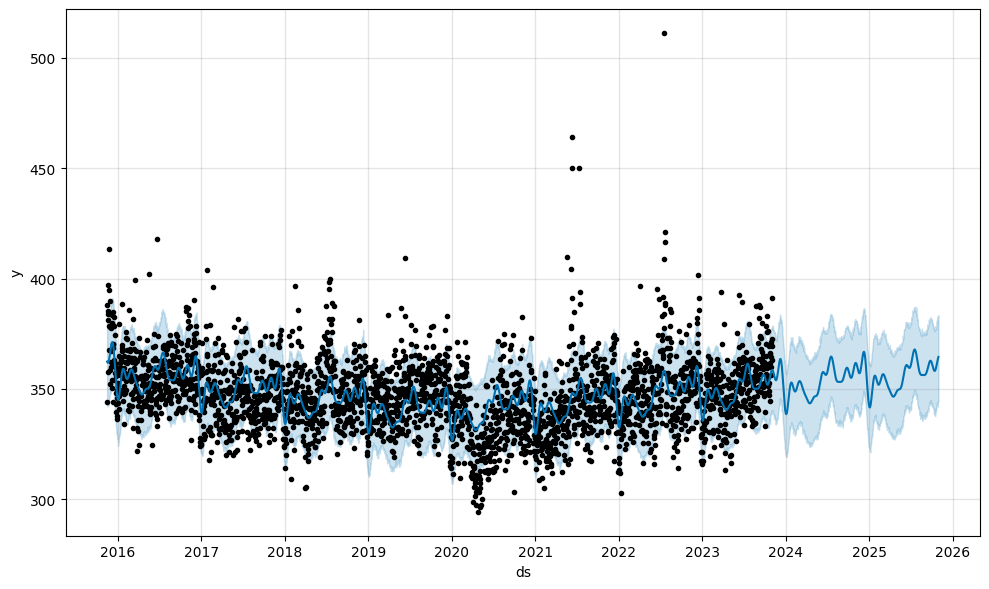

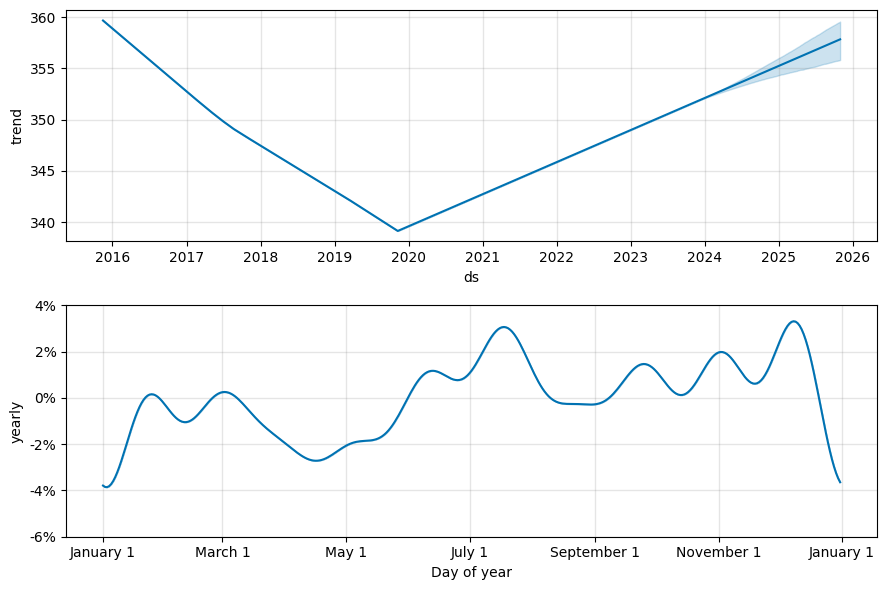

In [63]:
from sklearn.metrics import root_mean_squared_error
model_tuned.plot(predictions_tuned);
model_tuned.plot_components(predictions_tuned);

Root Mean Square Error (RMSE): 15.26385978006504


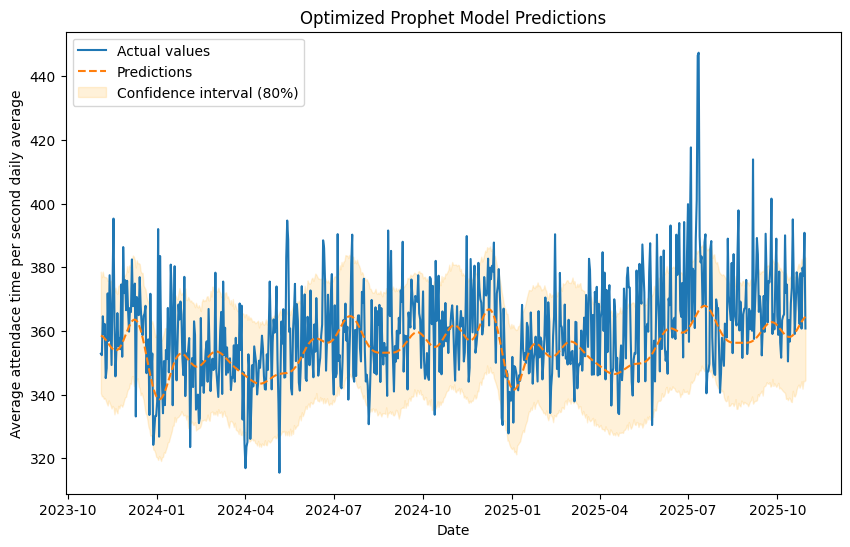

In [52]:
rmse = root_mean_squared_error(df_test['y'], predictions_tuned['yhat'].tail(727))
print(f'Root Mean Square Error (RMSE): {rmse}')
plt.figure(figsize=(10, 6))
plt.plot(df_test['ds'], df_ph['y'].tail(727), label='Actual values')
plt.plot(df_test['ds'], predictions_tuned['yhat'].tail(727), label='Predictions', linestyle='--')
plt.fill_between(df_test['ds'], predictions_tuned['yhat_lower'].tail(727), predictions_tuned['yhat_upper'].tail(727), 
                 color='orange', alpha=0.15, label='Confidence interval (80%)')
plt.title('Optimized Prophet Model Predictions')
plt.xlabel('Date')
plt.ylabel('Average attendace time per second daily average')
plt.legend()
plt.show()

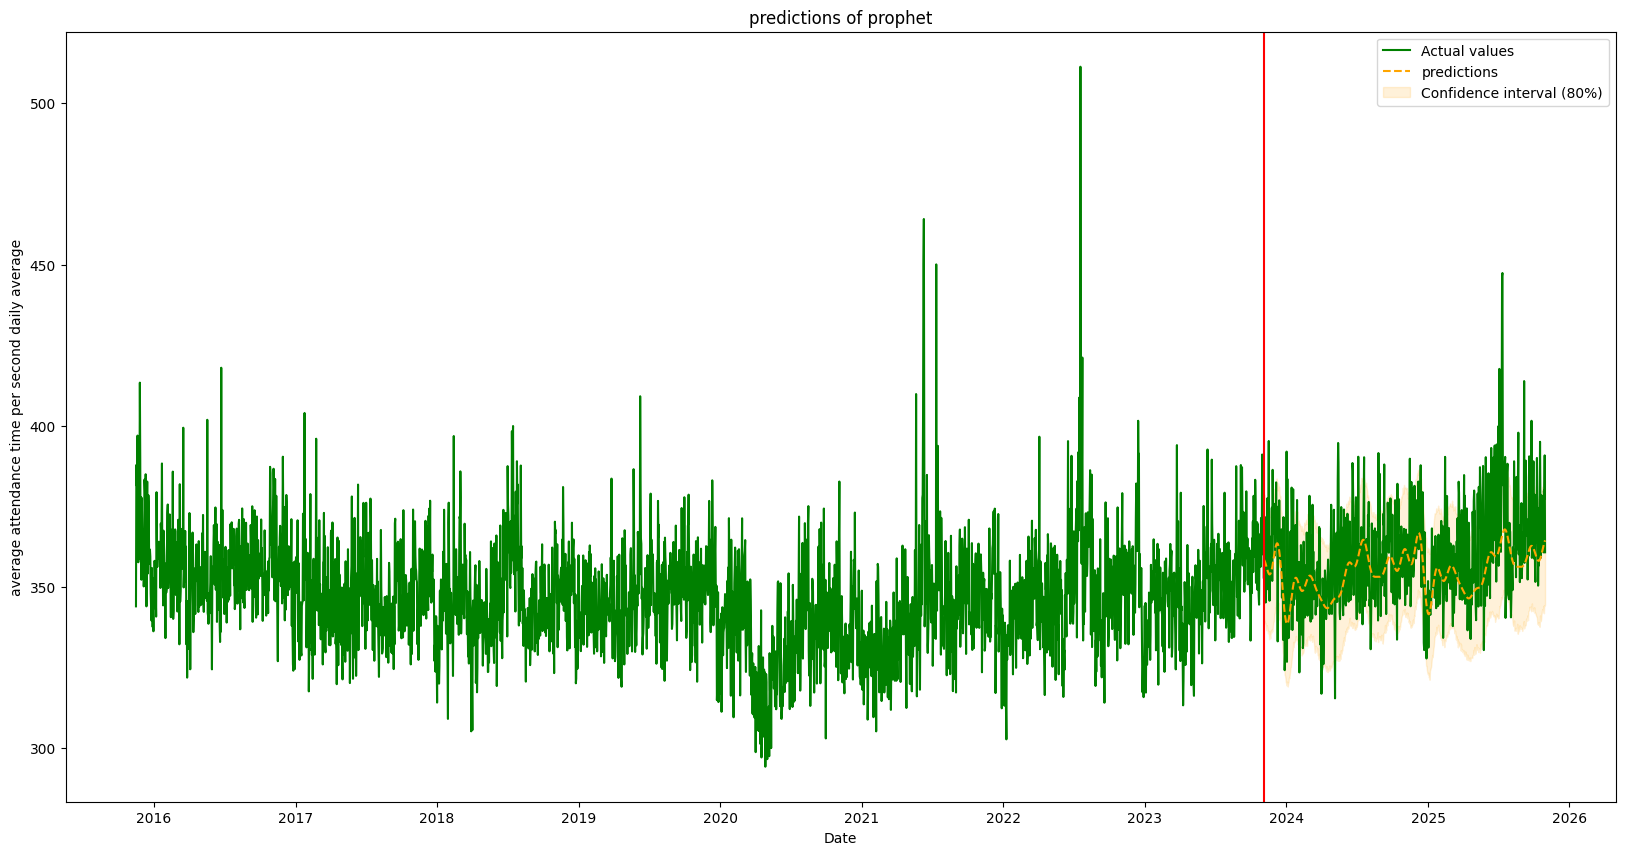

In [64]:
plt.figure(figsize=(20, 10))
plt.plot(df_ph['ds'], df_ph['y'], label='Actual values',color='green')
plt.plot(df_test['ds'], predictions_tuned['yhat'].tail(727), label='predictions', linestyle='--',color='orange')
plt.fill_between(df_test['ds'], predictions_tuned['yhat_lower'].tail(727), predictions_tuned['yhat_upper'].tail(727), 
                 color='orange', alpha=0.15, label='Confidence interval (80%)')
plt.axvline(x= datetime.date(2023,11,4), color='red');
plt.title('predictions of prophet')
plt.xlabel('Date')
plt.ylabel('average attendance time per second daily average')
plt.legend()
plt.show()

In [67]:
ts_new = df_clean[['TimeOfCall','Average_AttendanceTimeSeconds']]

In [71]:
ts_new = ts_new.reset_index(inplace=False)

In [72]:
ts_new['DateTime'] = pd.to_datetime(
    ts_new['DateOfCall'].astype(str) + ' ' + ts_new['TimeOfCall'].astype(str),
    errors='coerce'   # handle any mismatches gracefully
)

# Set that new column as the index
ts_new = ts_new.set_index('DateTime')

# Drop the original separate columns (optional but cleans up)
ts_new = ts_new.drop(['DateOfCall', 'TimeOfCall'], axis=1)

In [73]:
monthly_new = ts_new['Average_AttendanceTimeSeconds'].resample('M').mean().round().reset_index()

In [76]:
monthly_new.to_parquet(
    'data.parquet_monthly_new',
    compression='snappy',
    index=False,
    engine='fastparquet'  # Use fastparquet instead of pyarrow
)

In [114]:
monthly_new = pd.read_parquet('data.parquet_monthly_new', engine='fastparquet')

In [115]:
df_ph = monthly_new.copy()
df_ph = df_ph.rename(columns={"DateTime": "ds", "Average_AttendanceTimeSeconds": "y"})
df_ph.head()

,ds,y
0,2015-11-30,381.0
1,2015-12-31,361.0
2,2016-01-31,358.0
3,2016-02-29,359.0
4,2016-03-31,355.0


In [116]:
df_train = df_ph.iloc[:-24]
df_test = df_ph.iloc[-24:]

In [122]:
model_tuned_m = joblib.load('monthly_TS_model.pkl')

In [123]:
future = model_tuned_m.make_future_dataframe(periods=24, freq = 'ME')
predictions_tuned = model_tuned_m.predict(future)

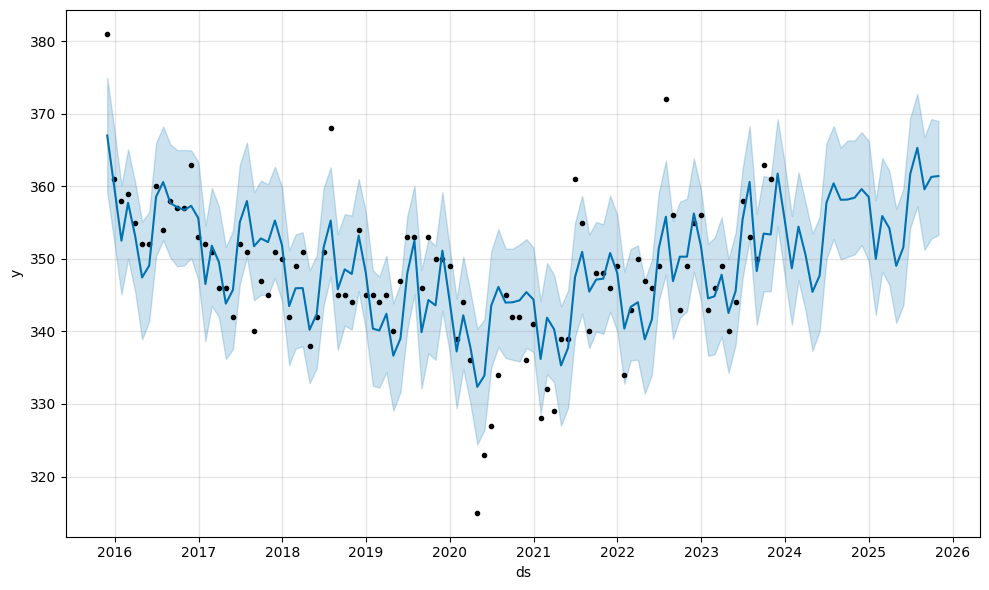

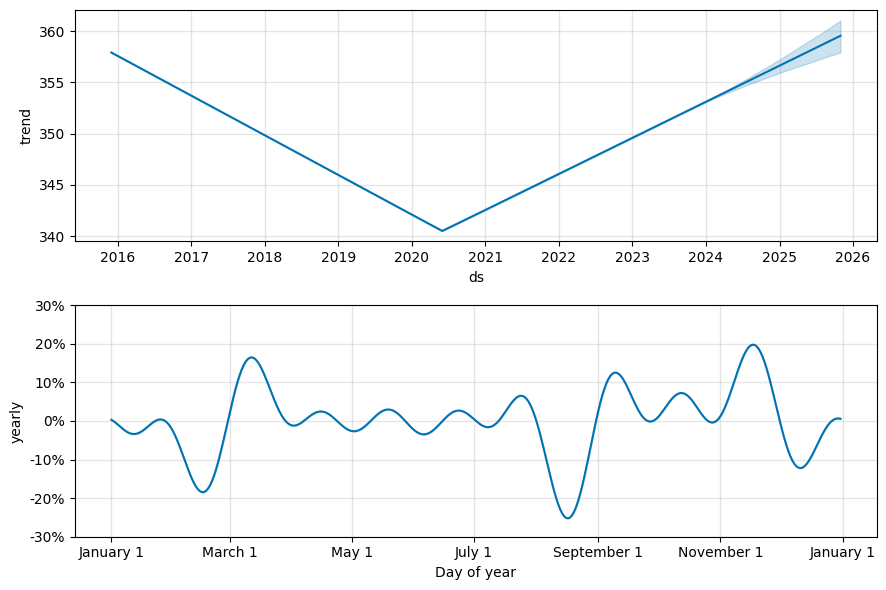

In [124]:
model_tuned.plot(predictions_tuned);
model_tuned.plot_components(predictions_tuned);

In [125]:
rmse = root_mean_squared_error(df_test['y'], predictions_tuned['yhat'].tail(24))
print(f'Root Mean Square Error (RMSE): {rmse}')

Root Mean Square Error (RMSE): 6.744249598132149


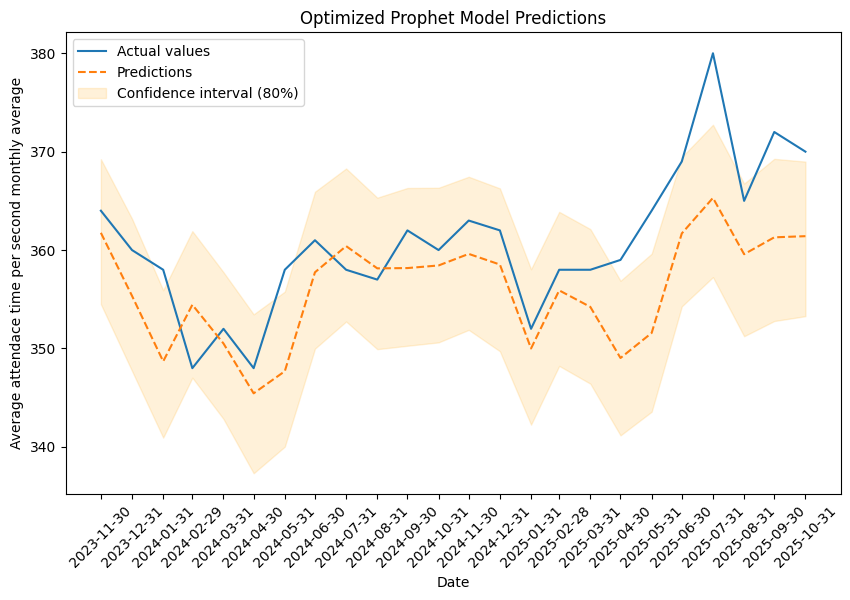

In [126]:
plt.figure(figsize=(10, 6))
plt.plot(df_test['ds'], df_ph['y'].tail(24), label='Actual values')
plt.plot(df_test['ds'], predictions_tuned['yhat'].tail(24), label='Predictions', linestyle='--')
plt.fill_between(df_test['ds'], predictions_tuned['yhat_lower'].tail(24), predictions_tuned['yhat_upper'].tail(24), 
                 color='orange', alpha=0.15, label='Confidence interval (80%)')
plt.title('Optimized Prophet Model Predictions')
plt.xlabel('Date')
plt.xticks(df_test['ds'], rotation=45)
plt.ylabel('Average attendace time per second monthly average')
plt.legend()
plt.show()

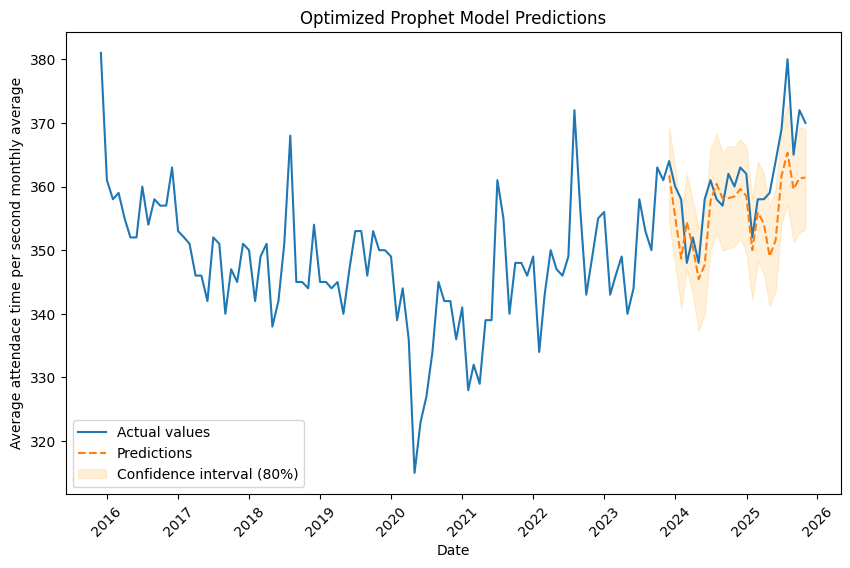

In [ ]:
df_ph_pt = df_ph.copy()
df_ph_pt = df_ph_pt.set_index('ds')
plt.figure(figsize=(10, 6))
plt.plot(df_ph_pt['y'], label='Actual values')
plt.plot(df_test['ds'], predictions_tuned['yhat'].tail(24), label='Predictions', linestyle='--')
plt.fill_between(df_test['ds'], predictions_tuned['yhat_lower'].tail(24), predictions_tuned['yhat_upper'].tail(24), 
                 color='orange', alpha=0.15, label='Confidence interval (80%)')
plt.title('Optimized Prophet Model Predictions')
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.ylabel('Average attendace time per second monthly average')
plt.legend()
plt.show()

In [4]:
df_clean_vis_filtered.columns.to_list

<bound method IndexOpsMixin.tolist of Index(['IncidentNumber', 'DateOfCall', 'CalYear', 'TimeOfCall', 'HourOfCall',
       'IncidentGroup', 'StopCodeDescription', 'SpecialServiceType',
       'PropertyCategory', 'PropertyType', 'AddressQualifier', 'Postcode_full',
       'Postcode_district', 'UPRN', 'USRN', 'IncGeo_BoroughCode',
       'IncGeo_BoroughName', 'ProperCase', 'IncGeo_WardCode',
       'IncGeo_WardName', 'IncGeo_WardNameNew', 'Easting_m', 'Northing_m',
       'Easting_rounded', 'Northing_rounded', 'Latitude', 'Longitude', 'FRS',
       'IncidentStationGround', 'FirstPumpArriving_AttendanceTime',
       'FirstPumpArriving_DeployedFromStation',
       'SecondPumpArriving_AttendanceTime',
       'SecondPumpArriving_DeployedFromStation',
       'NumStationsWithPumpsAttending', 'NumPumpsAttending', 'PumpCount',
       'PumpMinutesRounded', 'Notional Cost (£)', 'NumCalls',
       'Average_AttendanceTimeSeconds', 'DelayCodeId', 'Easting', 'Northing',
       'distance', 'Longitude_r

In [ ]:
# %%
# Standard Library
import os
import warnings
import datetime
from datetime import datetime as dt
from pathlib import Path

warnings.filterwarnings('ignore')

# Data Manipulation & Computation
import pandas as pd
import numpy as np
import pyarrow
from scipy.stats import pointbiserialr

# Geospatial
import pyproj
from pyproj import Transformer
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Dash App
import dash
import dash_bootstrap_components as dbc
from dash import dcc, html, dash_table
from dash.dependencies import Input, Output, State

# Machine Learning & Modeling
import xgboost as xgb
import lightgbm as lgb
import optuna
import joblib
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Initialize the Dash app
app = dash.Dash(__name__, external_stylesheets=['https://codepen.io/chriddyp/pen/bWLwgP.css'])
server = app.server
df = pd.read_parquet('data.parquet_df_clean_vis_filtered', engine='fastparquet')
# Fixed data preprocessing function
def preprocess_data(df):
    # Make a copy to avoid modifying the original
    df_processed = df.copy()

    # Convert date columns if needed
    if 'DateOfCall' in df_processed.columns:
        df_processed['DateOfCall'] = pd.to_datetime(df_processed['DateOfCall'], errors='coerce')
        df_processed['Month'] = df_processed['DateOfCall'].dt.month
        df_processed['DayOfWeek'] = df_processed['DateOfCall'].dt.day_name()

    # Handle categorical columns properly
    categorical_columns = ['IncidentGroup', 'StopCodeDescription', 'IncGeo_BoroughName']

    for col in categorical_columns:
        if col in df_processed.columns:
            # Convert to string first, then handle missing values
            df_processed[col] = df_processed[col].astype(str)
            df_processed[col] = df_processed[col].replace('nan', 'Unknown')
            df_processed[col] = df_processed[col].fillna('Unknown')
            # Convert back to categorical if it was categorical
            if hasattr(df[col], 'cat'):
                df_processed[col] = pd.Categorical(df_processed[col])

    return df_processed

# Alternative simpler preprocessing function
def preprocess_data_simple(df):
    """Simpler preprocessing that avoids categorical issues"""
    df_processed = df.copy()

    # Convert date columns
    if 'DateOfCall' in df_processed.columns:
        df_processed['DateOfCall'] = pd.to_datetime(df_processed['DateOfCall'], errors='coerce')
        df_processed['Month'] = df_processed['DateOfCall'].dt.month
        df_processed['DayOfWeek'] = df_processed['DateOfCall'].dt.day_name()

    # Convert potential categorical columns to string to avoid issues
    categorical_cols = ['IncidentGroup', 'StopCodeDescription', 'IncGeo_BoroughName', 'SpecialServiceType']

    for col in categorical_cols:
        if col in df_processed.columns:
            # Convert to string and handle missing values
            df_processed[col] = df_processed[col].astype(str)
            df_processed.loc[df_processed[col] == 'nan', col] = 'Unknown'
            df_processed[col] = df_processed[col].fillna('Unknown')

    return df_processed

# Preprocess your data (use the simple version to avoid issues)
df_processed = preprocess_data_simple(df)

# Get unique values for filters
available_years = sorted(df_processed['CalYear'].unique())
boroughs = sorted(df_processed['IncGeo_BoroughName'].unique())
incident_groups = sorted(df_processed['IncidentGroup'].unique())

# Remove 'Unknown' from filter options if present
boroughs = [b for b in boroughs if b != 'Unknown']
incident_groups = [ig for ig in incident_groups if ig != 'Unknown']

app.layout = html.Div([
    # Header
    html.Div([
        html.H1("London Fire Brigade Incident Records",
                style={'color': '#1a3f6c', 'marginBottom': '10px', 'fontWeight': 'bold'}),
        html.P("Interactive dashboard showing London Fire Brigade incident data",
               style={'color': '#666', 'fontSize': '16px'})
    ], style={'textAlign': 'center', 'padding': '20px', 'backgroundColor': '#f8f9fa', 'borderBottom': '2px solid #dee2e6'}),

    # Filters Section
    html.Div([
        html.Div([
            html.Label("Year Range:", style={'fontWeight': 'bold'}),
            dcc.RangeSlider(
                id='year-slider',
                min=available_years[0],
                max=available_years[-1],
                value=[available_years[-3], available_years[-1]],
                marks={str(year): str(year) for year in available_years if year % 2 == 0},
                step=1
            )
        ], style={'marginBottom': '20px'}),

        html.Div([
            html.Div([
                html.Label("Borough:", style={'fontWeight': 'bold'}),
                dcc.Dropdown(
                    id='borough-dropdown',
                    options=[{'label': 'All Boroughs', 'value': 'all'}] +
                            [{'label': borough, 'value': borough} for borough in boroughs],
                    value='all',
                    multi=False
                )
            ], style={'width': '32%', 'display': 'inline-block', 'marginRight': '1%'}),

            html.Div([
                html.Label("Incident Type:", style={'fontWeight': 'bold'}),
                dcc.Dropdown(
                    id='incident-type-dropdown',
                    options=[{'label': 'All Types', 'value': 'all'}] +
                            [{'label': inc_type, 'value': inc_type} for inc_type in incident_groups],
                    value='all',
                    multi=False
                )
            ], style={'width': '32%', 'display': 'inline-block', 'marginRight': '1%'}),

            html.Div([
                html.Label("Time Period:", style={'fontWeight': 'bold'}),
                dcc.Dropdown(
                    id='time-period-dropdown',
                    options=[
                        {'label': 'All Time', 'value': 'all'},
                        {'label': 'Last 7 Days', 'value': '7d'},
                        {'label': 'Last 30 Days', 'value': '30d'},
                        {'label': 'Last 90 Days', 'value': '90d'},
                        {'label': 'Last Year', 'value': '1y'}
                    ],
                    value='all'
                )
            ], style={'width': '32%', 'display': 'inline-block'})
        ], style={'marginBottom': '20px'})
    ], style={'padding': '20px', 'backgroundColor': 'white', 'borderBottom': '1px solid #dee2e6'}),

    # Key Metrics Section
    html.Div([
        html.Div([
            html.Div([
                html.H4("TOTAL INCIDENTS", style={'color': '#666', 'marginBottom': '5px', 'fontSize': '14px'}),
                html.H2(id="total-incidents", style={'color': '#1a3f6c', 'margin': '0', 'fontSize': '32px'})
            ], className='metric-box', style={'textAlign': 'center', 'padding': '15px', 'backgroundColor': 'white',
                                            'borderRadius': '5px', 'boxShadow': '0 2px 4px rgba(0,0,0,0.1)'}),
        ], style={'width': '24%', 'display': 'inline-block', 'padding': '10px'}),

        html.Div([
            html.Div([
                html.H4("FIRES", style={'color': '#666', 'marginBottom': '5px', 'fontSize': '14px'}),
                html.H2(id="fires-count", style={'color': '#dc3545', 'margin': '0', 'fontSize': '32px'})
            ], className='metric-box', style={'textAlign': 'center', 'padding': '15px', 'backgroundColor': 'white',
                                            'borderRadius': '5px', 'boxShadow': '0 2px 4px rgba(0,0,0,0.1)'}),
        ], style={'width': '24%', 'display': 'inline-block', 'padding': '10px'}),

        html.Div([
            html.Div([
                html.H4("SPECIAL SERVICES", style={'color': '#666', 'marginBottom': '5px', 'fontSize': '14px'}),
                html.H2(id="special-services-count", style={'color': '#28a745', 'margin': '0', 'fontSize': '32px'})
            ], className='metric-box', style={'textAlign': 'center', 'padding': '15px', 'backgroundColor': 'white',
                                            'borderRadius': '5px', 'boxShadow': '0 2px 4px rgba(0,0,0,0.1)'}),
        ], style={'width': '24%', 'display': 'inline-block', 'padding': '10px'}),

        html.Div([
            html.Div([
                html.H4("FALSE ALARMS", style={'color': '#666', 'marginBottom': '5px', 'fontSize': '14px'}),
                html.H2(id="false-alarms-count", style={'color': '#ffc107', 'margin': '0', 'fontSize': '32px'})
            ], className='metric-box', style={'textAlign': 'center', 'padding': '15px', 'backgroundColor': 'white',
                                            'borderRadius': '5px', 'boxShadow': '0 2px 4px rgba(0,0,0,0.1)'}),
        ], style={'width': '24%', 'display': 'inline-block', 'padding': '10px'})
    ], style={'padding': '20px', 'textAlign': 'center'}),

    # Charts Section
    html.Div([
        # First row of charts
        html.Div([
            html.Div([
                html.H4("Incidents by Type", style={'textAlign': 'center', 'color': '#1a3f6c'}),
                dcc.Graph(id='incident-type-chart')
            ], style={'width': '32%', 'display': 'inline-block', 'padding': '10px'}),

            html.Div([
                html.H4("Incidents by Hour of Day", style={'textAlign': 'center', 'color': '#1a3f6c'}),
                dcc.Graph(id='hourly-distribution-chart')
            ], style={'width': '32%', 'display': 'inline-block', 'padding': '10px'}),

            html.Div([
                html.H4("Monthly Trend", style={'textAlign': 'center', 'color': '#1a3f6c'}),
                dcc.Graph(id='monthly-trend-chart')
            ], style={'width': '32%', 'display': 'inline-block', 'padding': '10px'})
        ]),

        # Second row of charts
        html.Div([
            html.Div([
                html.H4("Top Boroughs", style={'textAlign': 'center', 'color': '#1a3f6c'}),
                dcc.Graph(id='borough-chart')
            ], style={'width': '48%', 'display': 'inline-block', 'padding': '10px'}),

            html.Div([
                html.H4("Incident Response Times", style={'textAlign': 'center', 'color': '#1a3f6c'}),
                dcc.Graph(id='response-time-chart')
            ], style={'width': '48%', 'display': 'inline-block', 'padding': '10px'})
        ])
    ], style={'padding': '20px', 'backgroundColor': '#f8f9fa'}),

    # Data Table Section
    html.Div([
        html.H4("Incident Details", style={'color': '#1a3f6c', 'marginBottom': '15px'}),
        html.Div([
            dcc.Dropdown(
                id='table-page-size',
                options=[
                    {'label': 'Show 10 rows', 'value': 10},
                    {'label': 'Show 25 rows', 'value': 25},
                    {'label': 'Show 50 rows', 'value': 50}
                ],
                value=10,
                style={'width': '200px', 'marginBottom': '10px'}
            )
        ]),
        html.Div(id='incidents-table-container')
    ], style={'padding': '20px'}),

    # Download Section
    html.Div([
        html.H4("Download Filtered Data", style={'color': '#1a3f6c', 'marginBottom': '15px'}),
        html.Button("Download CSV", id="btn-download-csv",
                   style={'backgroundColor': '#1a3f6c', 'color': 'white', 'padding': '10px 20px', 'border': 'none', 'borderRadius': '5px'}),
        dcc.Download(id="download-dataframe-csv")
    ], style={'padding': '20px', 'borderTop': '1px solid #dee2e6'})
])

# Callback to update all components based on filters
@app.callback(
    [Output('total-incidents', 'children'),
     Output('fires-count', 'children'),
     Output('special-services-count', 'children'),
     Output('false-alarms-count', 'children'),
     Output('incident-type-chart', 'figure'),
     Output('hourly-distribution-chart', 'figure'),
     Output('monthly-trend-chart', 'figure'),
     Output('borough-chart', 'figure'),
     Output('response-time-chart', 'figure'),
     Output('incidents-table-container', 'children')],
    [Input('year-slider', 'value'),
     Input('borough-dropdown', 'value'),
     Input('incident-type-dropdown', 'value'),
     Input('time-period-dropdown', 'value'),
     Input('table-page-size', 'value')]
)
def update_dashboard(selected_years, selected_borough, selected_incident_type, selected_time_period, page_size):
    # Filter data based on selections
    filtered_df = df_processed.copy()

    # Year filter
    filtered_df = filtered_df[
        (filtered_df['CalYear'] >= selected_years[0]) &
        (filtered_df['CalYear'] <= selected_years[1])
    ]

    # Borough filter
    if selected_borough != 'all':
        filtered_df = filtered_df[filtered_df['IncGeo_BoroughName'] == selected_borough]

    # Incident type filter
    if selected_incident_type != 'all':
        filtered_df = filtered_df[filtered_df['IncidentGroup'] == selected_incident_type]

    # Time period filter (only if DateOfCall exists)
    if selected_time_period != 'all' and 'DateOfCall' in filtered_df.columns:
        today = pd.Timestamp.now()
        if selected_time_period == '7d':
            cutoff_date = today - pd.Timedelta(days=7)
        elif selected_time_period == '30d':
            cutoff_date = today - pd.Timedelta(days=30)
        elif selected_time_period == '90d':
            cutoff_date = today - pd.Timedelta(days=90)
        elif selected_time_period == '1y':
            cutoff_date = today - pd.Timedelta(days=365)

        filtered_df = filtered_df[filtered_df['DateOfCall'] >= cutoff_date]

    # Calculate metrics
    total_incidents = len(filtered_df)
    fires_count = len(filtered_df[filtered_df['IncidentGroup'] == 'Fire'])
    special_services_count = len(filtered_df[filtered_df['IncidentGroup'] == 'Special Service'])
    false_alarms_count = len(filtered_df[filtered_df['IncidentGroup'] == 'False Alarm'])

    # Format numbers with commas
    total_incidents_str = f"{total_incidents:,}"
    fires_count_str = f"{fires_count:,}"
    special_services_str = f"{special_services_count:,}"
    false_alarms_str = f"{false_alarms_count:,}"

    # 1. Incident Type Chart (Pie)
    incident_type_data = filtered_df['IncidentGroup'].value_counts()
    incident_type_fig = px.pie(
        values=incident_type_data.values,
        names=incident_type_data.index,
        color=incident_type_data.index,
        color_discrete_map={
            'Fire': '#dc3545',
            'Special Service': '#28a745',
            'False Alarm': '#ffc107'
        }
    )
    incident_type_fig.update_layout(showlegend=True, margin=dict(t=30, b=0, l=0, r=0))

    # 2. Hourly Distribution Chart
    hourly_data = filtered_df['HourOfCall'].value_counts().sort_index()
    hourly_fig = go.Figure()
    hourly_fig.add_trace(go.Bar(
        x=hourly_data.index,
        y=hourly_data.values,
        marker_color='#1a3f6c',
        opacity=0.8
    ))
    hourly_fig.update_layout(
        xaxis_title='Hour of Day',
        yaxis_title='Number of Incidents',
        showlegend=False,
        margin=dict(t=30, b=0, l=0, r=0)
    )

    # 3. Monthly Trend Chart
    monthly_trend = filtered_df.groupby(['CalYear', 'IncidentGroup']).size().reset_index(name='Count')
    trend_fig = px.line(
        monthly_trend,
        x='CalYear',
        y='Count',
        color='IncidentGroup',
        color_discrete_map={
            'Fire': '#dc3545',
            'Special Service': '#28a745',
            'False Alarm': '#ffc107'
        }
    )
    trend_fig.update_layout(
        xaxis_title='Year',
        yaxis_title='Number of Incidents',
        margin=dict(t=30, b=0, l=0, r=0)
    )

    # 4. Borough Chart
    borough_data = filtered_df['IncGeo_BoroughName'].value_counts().head(10)
    borough_fig = px.bar(
        x=borough_data.values,
        y=borough_data.index,
        orientation='h',
        color=borough_data.values,
        color_continuous_scale='Blues'
    )
    borough_fig.update_layout(
        xaxis_title='Number of Incidents',
        yaxis_title='Borough',
        showlegend=False,
        margin=dict(t=30, b=0, l=0, r=0)
    )

    # 5. Response Time Chart (if data available)
    response_time_fig = go.Figure()
    if 'FirstPumpArriving_AttendanceTime' in filtered_df.columns:
        # Convert to numeric and remove non-numeric values
        filtered_df['ResponseTime'] = pd.to_numeric(filtered_df['FirstPumpArriving_AttendanceTime'], errors='coerce')
        response_times = filtered_df.groupby('IncidentGroup')['ResponseTime'].mean().dropna()

        if not response_times.empty:
            response_time_fig.add_trace(go.Bar(
                x=response_times.index,
                y=response_times.values,
                marker_color=['#dc3545', '#28a745', '#ffc107']
            ))
        else:
            response_time_fig.add_annotation(text="No response time data available",
                                           xref="paper", yref="paper",
                                           x=0.5, y=0.5, showarrow=False)
    else:
        response_time_fig.add_annotation(text="Response time data not available",
                                       xref="paper", yref="paper",
                                       x=0.5, y=0.5, showarrow=False)

    response_time_fig.update_layout(
        xaxis_title='Incident Type',
        yaxis_title='Average Response Time (Seconds)',
        margin=dict(t=30, b=0, l=0, r=0)
    )

    # 6. Data Table
    table_columns = ['IncidentNumber', 'DateOfCall', 'IncidentGroup', 'StopCodeDescription', 'IncGeo_BoroughName']
    available_columns = [col for col in table_columns if col in filtered_df.columns]

    table_data = filtered_df[available_columns].head(page_size)

    table = dash_table.DataTable(
        data=table_data.to_dict('records'),
        columns=[{'name': i, 'id': i} for i in available_columns],
        style_cell={'textAlign': 'left', 'padding': '10px'},
        style_header={
            'backgroundColor': '#1a3f6c',
            'color': 'white',
            'fontWeight': 'bold'
        },
        style_data={
            'backgroundColor': 'white',
            'color': 'black'
        },
        page_size=page_size
    )

    return (total_incidents_str, fires_count_str, special_services_str, false_alarms_str,
            incident_type_fig, hourly_fig, trend_fig, borough_fig, response_time_fig, table)

# Download callback
@app.callback(
    Output("download-dataframe-csv", "data"),
    Input("btn-download-csv", "n_clicks"),
    [State('year-slider', 'value'),
     State('borough-dropdown', 'value'),
     State('incident-type-dropdown', 'value'),
     State('time-period-dropdown', 'value')],
    prevent_initial_call=True,
)
def download_csv(n_clicks, selected_years, selected_borough, selected_incident_type, selected_time_period):
    # Apply the same filters as the main callback
    filtered_df = df_processed.copy()
    filtered_df = filtered_df[
        (filtered_df['CalYear'] >= selected_years[0]) &
        (filtered_df['CalYear'] <= selected_years[1])
    ]

    if selected_borough != 'all':
        filtered_df = filtered_df[filtered_df['IncGeo_BoroughName'] == selected_borough]

    if selected_incident_type != 'all':
        filtered_df = filtered_df[filtered_df['IncidentGroup'] == selected_incident_type]

    return dcc.send_data_frame(filtered_df.to_csv, "lfb_incidents_filtered.csv")


print('visit http://127.0.0.1:8050')
app.run(debug=False,port=8050)
print("Press Enter to exit...")
input()  # Wait for Enter key
print("Exiting program...")

visit http://127.0.0.1:8050


Press Enter to exit...
Exiting program...


[2026-06-15 00:23:41,441] ERROR in app: Exception on /_dash-update-component [POST]
Traceback (most recent call last):
  File "c:\Users\mohamhussein\my codes\ds project files\.venv\Lib\site-packages\flask\app.py", line 1511, in wsgi_app
    response = self.full_dispatch_request()
  File "c:\Users\mohamhussein\my codes\ds project files\.venv\Lib\site-packages\flask\app.py", line 919, in full_dispatch_request
    rv = self.handle_user_exception(e)
  File "c:\Users\mohamhussein\my codes\ds project files\.venv\Lib\site-packages\flask\app.py", line 917, in full_dispatch_request
    rv = self.dispatch_request()
  File "c:\Users\mohamhussein\my codes\ds project files\.venv\Lib\site-packages\flask\app.py", line 902, in dispatch_request
    return self.ensure_sync(self.view_functions[rule.endpoint])(**view_args)  # type: ignore[no-any-return]
           ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^
  File "c:\Users\mohamhussein\my codes\ds project files\.venv\Lib\site-packag